# Assignment-1: Image Prediction and Feature Visualization
[Click Here - Github Link](https://github.com/nazmulhasan77/Deep_Learning/tree/main/Assignment_1_Image%20Prediction%20and%20Feature%20Visualization)
## Course Information
- **Course Title:** Neural Networks and Deep Learning  
- **Submitted To:** Sangeeta Biswas  

## Student Information
- **Name:** Md Nazmul Hasan  
- **Student ID:** 2111176131  
- **Department:** Computer Science and Engineering  
- **University:** University of Rajshahi  

### 1. Face Image Collection
* Capture images of your own face, along with those of three male and three female friends or relatives, from five different angles using your mobile phone.
* Make sure to obtain full consent from all participants before capturing their images.

### 2. Flower Image Collection
* Capture five images each of five different types of flowers using your phone.

### 3. Classification Using Pre-trained Models
* Use 10 pre-trained classifiers available in Keras to predict:
  * Top-1 prediction
  * Top-5 predictions
* Perform these predictions for both the captured face images and flower images.

In [ ]:
import os
import gc
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import tensorflow as tf

# ================= FORCE CPU ONLY =================
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'   # This disables GPU completely# Extra safety

print("🚀 Running on CPU only (GPU disabled)")

# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()

# ================= CHOOSE ONE MODEL =================
model_name = "ResNet50"
model_options = {
    "VGG16": ("VGG16", 224),
    "VGG19": ("VGG19", 224),
    "ResNet50": ("ResNet50", 224),
    "InceptionV3": ("InceptionV3", 299),
    "Xception": ("Xception", 299),
    "DenseNet121": ("DenseNet121", 224),
    "MobileNet": ("MobileNet", 224),
    "MobileNetV2": ("MobileNetV2", 224),
    "NASNetMobile": ("NASNetMobile", 224),
    "EfficientNetB0": ("EfficientNetB0", 224),
}

if model_name not in model_options:
    raise ValueError(f"Model '{model_name}' not supported!")

builder_name, input_size = model_options[model_name]

# Dynamic import of the chosen model and its preprocess function
if model_name == "VGG16":
    from tensorflow.keras.applications import VGG16 as ModelBuilder
    from tensorflow.keras.applications.vgg16 import preprocess_input
elif model_name == "VGG19":
    from tensorflow.keras.applications import VGG19 as ModelBuilder
    from tensorflow.keras.applications.vgg19 import preprocess_input
elif model_name == "ResNet50":
    from tensorflow.keras.applications import ResNet50 as ModelBuilder
    from tensorflow.keras.applications.resnet50 import preprocess_input
elif model_name == "InceptionV3":
    from tensorflow.keras.applications import InceptionV3 as ModelBuilder
    from tensorflow.keras.applications.inception_v3 import preprocess_input
elif model_name == "Xception":
    from tensorflow.keras.applications import Xception as ModelBuilder
    from tensorflow.keras.applications.xception import preprocess_input
elif model_name == "DenseNet121":
    from tensorflow.keras.applications import DenseNet121 as ModelBuilder
    from tensorflow.keras.applications.densenet import preprocess_input
elif model_name == "MobileNet":
    from tensorflow.keras.applications import MobileNet as ModelBuilder
    from tensorflow.keras.applications.mobilenet import preprocess_input
elif model_name == "MobileNetV2":
    from tensorflow.keras.applications import MobileNetV2 as ModelBuilder
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
elif model_name == "NASNetMobile":
    from tensorflow.keras.applications import NASNetMobile as ModelBuilder
    from tensorflow.keras.applications.nasnet import preprocess_input
elif model_name == "EfficientNetB0":
    from tensorflow.keras.applications import EfficientNetB0 as ModelBuilder
    from tensorflow.keras.applications.efficientnet import preprocess_input

print(f"\nLoading {model_name} on CPU... (this may take a few seconds)")

# Load the model
model = ModelBuilder(weights='imagenet', include_top=True)

# ================= YOUR IMAGE PATHS =================
flower_path = "dataset/flowers/Sunflower (8).jpg"
face_path   = "dataset/faces/Nazmul (5).jpg"

def predict_one_image(img_path, image_type):
    print(f"\n=== {model_name} Prediction on {image_type} ===")
    
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(input_size, input_size))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    
    # Predict
    preds = model.predict(x, verbose=0)
    
    # Decode predictions
    decoded = decode_predictions(preds, top=5)[0]
    
    print(f"Top-1: {decoded[0][1]} ({decoded[0][2]:.4f})")
    print("Top-5 Predictions:")
    for i, (_, label, score) in enumerate(decoded, 1):
        print(f"   {i}. {label}  ({score:.4f})")

# ============= RUN ON BOTH IMAGES =============
predict_one_image(flower_path, "Flower (Sunflower)")
predict_one_image(face_path,   "Face (Nazmul)")

# Clean up memory
del model
tf.keras.backend.clear_session()
gc.collect()

print(f"\n✅ {model_name} predictions completed successfully on CPU!")

🚀 Running on CPU only (GPU disabled)

Loading ResNet50 on CPU... (this may take a few seconds)

=== ResNet50 Prediction on Flower (Sunflower) ===
Top-1: daisy (0.9353)
Top-5 Predictions:
   1. daisy  (0.9353)
   2. vase  (0.0155)
   3. bee  (0.0151)
   4. ant  (0.0079)
   5. pot  (0.0047)

=== ResNet50 Prediction on Face (Nazmul) ===
Top-1: neck_brace (0.5152)
Top-5 Predictions:
   1. neck_brace  (0.5152)
   2. bow_tie  (0.1025)
   3. barbershop  (0.0855)
   4. wig  (0.0723)
   5. sunglasses  (0.0261)

✅ ResNet50 predictions completed successfully on CPU!


In [ ]:
import os
import gc
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import tensorflow as tf

# ================= FORCE CPU ONLY =================
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

print("🚀 Running ALL models on CPU only (GPU disabled)\n")

# Clear session
tf.keras.backend.clear_session()
gc.collect()

# ================= 10 MODELS LIST =================
models_config = [
    ("VGG16", 224),
    ("VGG19", 224),
    ("ResNet50", 224),
    ("InceptionV3", 299),
    ("Xception", 299),
    ("DenseNet121", 224),
    ("MobileNet", 224),
    ("MobileNetV2", 224),
    ("NASNetMobile", 224),
    ("EfficientNetB0", 224),
]

# ================= IMAGE PATHS =================
flower_path = "dataset/flowers/Sunflower (8).jpg"
face_path   = "dataset/faces/Nazmul (5).jpg"

# Store results for table
results = {"Flower": {}, "Face": {}}

def get_model_and_preprocess(model_name):
    if model_name == "VGG16":
        from tensorflow.keras.applications import VGG16 as Builder
        from tensorflow.keras.applications.vgg16 import preprocess_input
    elif model_name == "VGG19":
        from tensorflow.keras.applications import VGG19 as Builder
        from tensorflow.keras.applications.vgg19 import preprocess_input
    elif model_name == "ResNet50":
        from tensorflow.keras.applications import ResNet50 as Builder
        from tensorflow.keras.applications.resnet50 import preprocess_input
    elif model_name == "InceptionV3":
        from tensorflow.keras.applications import InceptionV3 as Builder
        from tensorflow.keras.applications.inception_v3 import preprocess_input
    elif model_name == "Xception":
        from tensorflow.keras.applications import Xception as Builder
        from tensorflow.keras.applications.xception import preprocess_input
    elif model_name == "DenseNet121":
        from tensorflow.keras.applications import DenseNet121 as Builder
        from tensorflow.keras.applications.densenet import preprocess_input
    elif model_name == "MobileNet":
        from tensorflow.keras.applications import MobileNet as Builder
        from tensorflow.keras.applications.mobilenet import preprocess_input
    elif model_name == "MobileNetV2":
        from tensorflow.keras.applications import MobileNetV2 as Builder
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    elif model_name == "NASNetMobile":
        from tensorflow.keras.applications import NASNetMobile as Builder
        from tensorflow.keras.applications.nasnet import preprocess_input
    elif model_name == "EfficientNetB0":
        from tensorflow.keras.applications import EfficientNetB0 as Builder
        from tensorflow.keras.applications.efficientnet import preprocess_input
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return Builder, preprocess_input

def predict_one_image(model_name, img_path, image_type):
    print(f"\n{'='*60}")
    print(f"Running {model_name} on {image_type}...")
    print(f"{'='*60}")
    
    Builder, preprocess_input = get_model_and_preprocess(model_name)
    
    # Load model
    model = Builder(weights='imagenet', include_top=True)
    
    # Load & preprocess image
    img = image.load_img(img_path, target_size=(input_size, input_size))  # input_size will be defined below
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    
    # Predict
    preds = model.predict(x, verbose=0)
    decoded = decode_predictions(preds, top=5)[0]
    
    # Print detailed result
    print(f"Top-1: {decoded[0][1]} ({decoded[0][2]:.4f})")
    print("Top-5:")
    for i, (_, label, score) in enumerate(decoded, 1):
        print(f"   {i}. {label} ({score:.4f})")
    
    # Save for table
    top1_label = decoded[0][1]
    top1_score = decoded[0][2]
    
    if image_type.startswith("Flower"):
        results["Flower"][model_name] = (top1_label, round(top1_score, 4))
    else:
        results["Face"][model_name] = (top1_label, round(top1_score, 4))
    
    # Clean up
    del model
    tf.keras.backend.clear_session()
    gc.collect()

# ================= RUN ALL MODELS =================
print("Starting classification with 10 pre-trained models on CPU...\n")

for model_name, input_size in models_config:
    # Flower
    predict_one_image(model_name, flower_path, "Flower (Sunflower)")
    
    # Face
    predict_one_image(model_name, face_path, "Face (Nazmul)")

# ================= FINAL TABLE SUMMARY =================
print("\n" + "="*80)
print("FINAL SUMMARY TABLE - Top-1 Predictions")
print("="*80)

print(f"{'Model':<15} | {'Flower (Sunflower)':<35} | {'Face (Nazmul)':<35}")
print("-" * 80)

for model_name, _ in models_config:
    flower_pred = results["Flower"].get(model_name, ("N/A", 0))
    face_pred   = results["Face"].get(model_name, ("N/A", 0))
    
    print(f"{model_name:<15} | {flower_pred[0]:<20} ({flower_pred[1]:.4f}) | "
          f"{face_pred[0]:<20} ({face_pred[1]:.4f})")

print("="*80)
print("✅ All 10 models completed successfully on CPU!")

### Final Summary Table - Top-1 Predictions

| Model          | Flower (Sunflower)          | Face (Nazmul)              |
|----------------|-----------------------------|----------------------------|
| VGG16          | daisy (0.9135)             | barbershop (0.1105)       |
| VGG19          | daisy (0.8510)             | barbershop (0.1230)       |
| ResNet50       | daisy (0.9353)             | neck_brace (0.5152)       |
| InceptionV3    | daisy (0.8962)             | neck_brace (0.7620)       |
| Xception       | daisy (0.9393)             | neck_brace (0.6005)       |
| DenseNet121    | daisy (0.8082)             | barbershop (0.1424)       |
| MobileNet      | daisy (0.8903)             | neck_brace (0.8325)       |
| MobileNetV2    | daisy (0.7627)             | hair_slide (0.0528)       |
| NASNetMobile   | daisy (0.8940)             | wig (0.1859)              |
| EfficientNetB0 | daisy (0.8781)             | neck_brace (0.1200)       |


## 4. Feature Extraction and Visualization
* Analyze the feature extraction capability of the selected pre-trained models by:
  * Extracting high-dimensional feature vectors.
  * Reducing them to a 2D representation using three dimensionality reduction techniques (e.g., PCA, t-SNE, UMAP).
  * Plotting and comparing the results.

### PART 1: Setup + Feature Extraction

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import *
import tensorflow as tf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

# ====================== PATHS ======================
faces_dir   = 'dataset/faces'
flowers_dir = 'dataset/flowers'

# Collect all images
def get_images_and_labels():
    image_paths = []
    labels = []
    
    # Faces
    for root, _, files in os.walk(faces_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, f))
                labels.append('Face')
    
    # Flowers
    for root, _, files in os.walk(flowers_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, f))
                labels.append('Flower')
    
    return image_paths, labels

image_paths, labels = get_images_and_labels()
print(f"Total images: {len(image_paths)} | Faces: {labels.count('Face')} | Flowers: {labels.count('Flower')}")

# ====================== 10 MODELS ======================
models_dict = {
    'VGG16': VGG16,
    'VGG19': VGG19,
    'ResNet50': ResNet50,
    'InceptionV3': InceptionV3,
    'Xception': Xception,
    'DenseNet121': DenseNet121,
    'MobileNet': MobileNet,
    'MobileNetV2': MobileNetV2,
    'NASNetMobile': NASNetMobile,
    'EfficientNetB0': EfficientNetB0
}

def get_preprocess_input(model_name):
    if model_name in ['VGG16', 'VGG19', 'ResNet50', 'DenseNet121', 'MobileNet', 'MobileNetV2', 'NASNetMobile']:
        from tensorflow.keras.applications.vgg16 import preprocess_input
    elif model_name in ['InceptionV3', 'Xception']:
        from tensorflow.keras.applications.inception_v3 import preprocess_input
    elif model_name == 'EfficientNetB0':
        from tensorflow.keras.applications.efficientnet import preprocess_input
    else:
        from tensorflow.keras.applications.imagenet_utils import preprocess_input
    return preprocess_input

def extract_features(model_name, batch_size=8):
    model_class = models_dict[model_name]
    target_size = (299, 299) if model_name in ['InceptionV3', 'Xception'] else (224, 224)
    
    base_model = model_class(weights='imagenet', include_top=False, pooling='avg')
    preprocess_input = get_preprocess_input(model_name)
    
    features_list = []
    print(f"Extracting features with {model_name} ...")
    
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []
        
        for p in batch_paths:
            try:
                img = image.load_img(p, target_size=target_size)
                x = image.img_to_array(img)
                batch_imgs.append(x)
            except:
                continue
                
        if not batch_imgs:
            continue
            
        batch_imgs = np.array(batch_imgs)
        batch_imgs = preprocess_input(batch_imgs)
        batch_features = base_model.predict(batch_imgs, verbose=0)
        features_list.append(batch_features)
    
    features = np.vstack(features_list)
    print(f"✓ {model_name} → Features shape: {features.shape}")
    return features

Total images: 117 | Faces: 44 | Flowers: 73


### PART 2: PCA for All 10 Models

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("\n=== PART 2: Running PCA for all 10 models ===")

pca_plots = []
for model_name in models_dict.keys():
    features = extract_features(model_name)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    pca = PCA(n_components=2, random_state=42)
    embedding = pca.fit_transform(features_scaled)
    
    df = pd.DataFrame(embedding, columns=['PC1', 'PC2'])
    df['label'] = labels
    
    # Save individual plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label', palette='Set2', s=120, edgecolor='black')
    plt.title(f'{model_name} - PCA\nExplained Variance: {pca.explained_variance_ratio_.sum():.2%}')
    plt.savefig(f"{model_name}_PCA.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    pca_plots.append((model_name, df))
    print(f"✓ PCA done for {model_name}")

# ================ 10×2 GRID for PCA ================
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.ravel()

for i, (model_name, df) in enumerate(pca_plots):
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label', 
                    palette='Set2', s=100, edgecolor='black', ax=axes[i])
    axes[i].set_title(f'{model_name} - PCA')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('PCA Visualization - All 10 Models (5×2 Grid)', fontsize=20, y=0.98)
plt.tight_layout()
plt.savefig("ALL_MODELS_PCA_Grid.png", dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: ALL_MODELS_PCA_Grid.png")

![ALL MODELS PCA Grid](ALL_MODELS_PCA_Grid.png)

### PART 3: t-SNE for All 10 Models


=== PART 3: Running t-SNE for all 10 models ===
Extracting features with VGG16 ...
✓ VGG16 → Features shape: (117, 512)
✓ t-SNE done for VGG16
Extracting features with VGG19 ...
✓ VGG19 → Features shape: (117, 512)
✓ t-SNE done for VGG19
Extracting features with ResNet50 ...
✓ ResNet50 → Features shape: (117, 2048)
✓ t-SNE done for ResNet50
Extracting features with InceptionV3 ...
✓ InceptionV3 → Features shape: (117, 2048)
✓ t-SNE done for InceptionV3
Extracting features with Xception ...
✓ Xception → Features shape: (117, 2048)
✓ t-SNE done for Xception
Extracting features with DenseNet121 ...
✓ DenseNet121 → Features shape: (117, 1024)
✓ t-SNE done for DenseNet121
Extracting features with MobileNet ...
✓ MobileNet → Features shape: (117, 1024)
✓ t-SNE done for MobileNet
Extracting features with MobileNetV2 ...
✓ MobileNetV2 → Features shape: (117, 1280)
✓ t-SNE done for MobileNetV2
Extracting features with NASNetMobile ...
✓ NASNetMobile → Features shape: (117, 1056)
✓ t-SNE done f

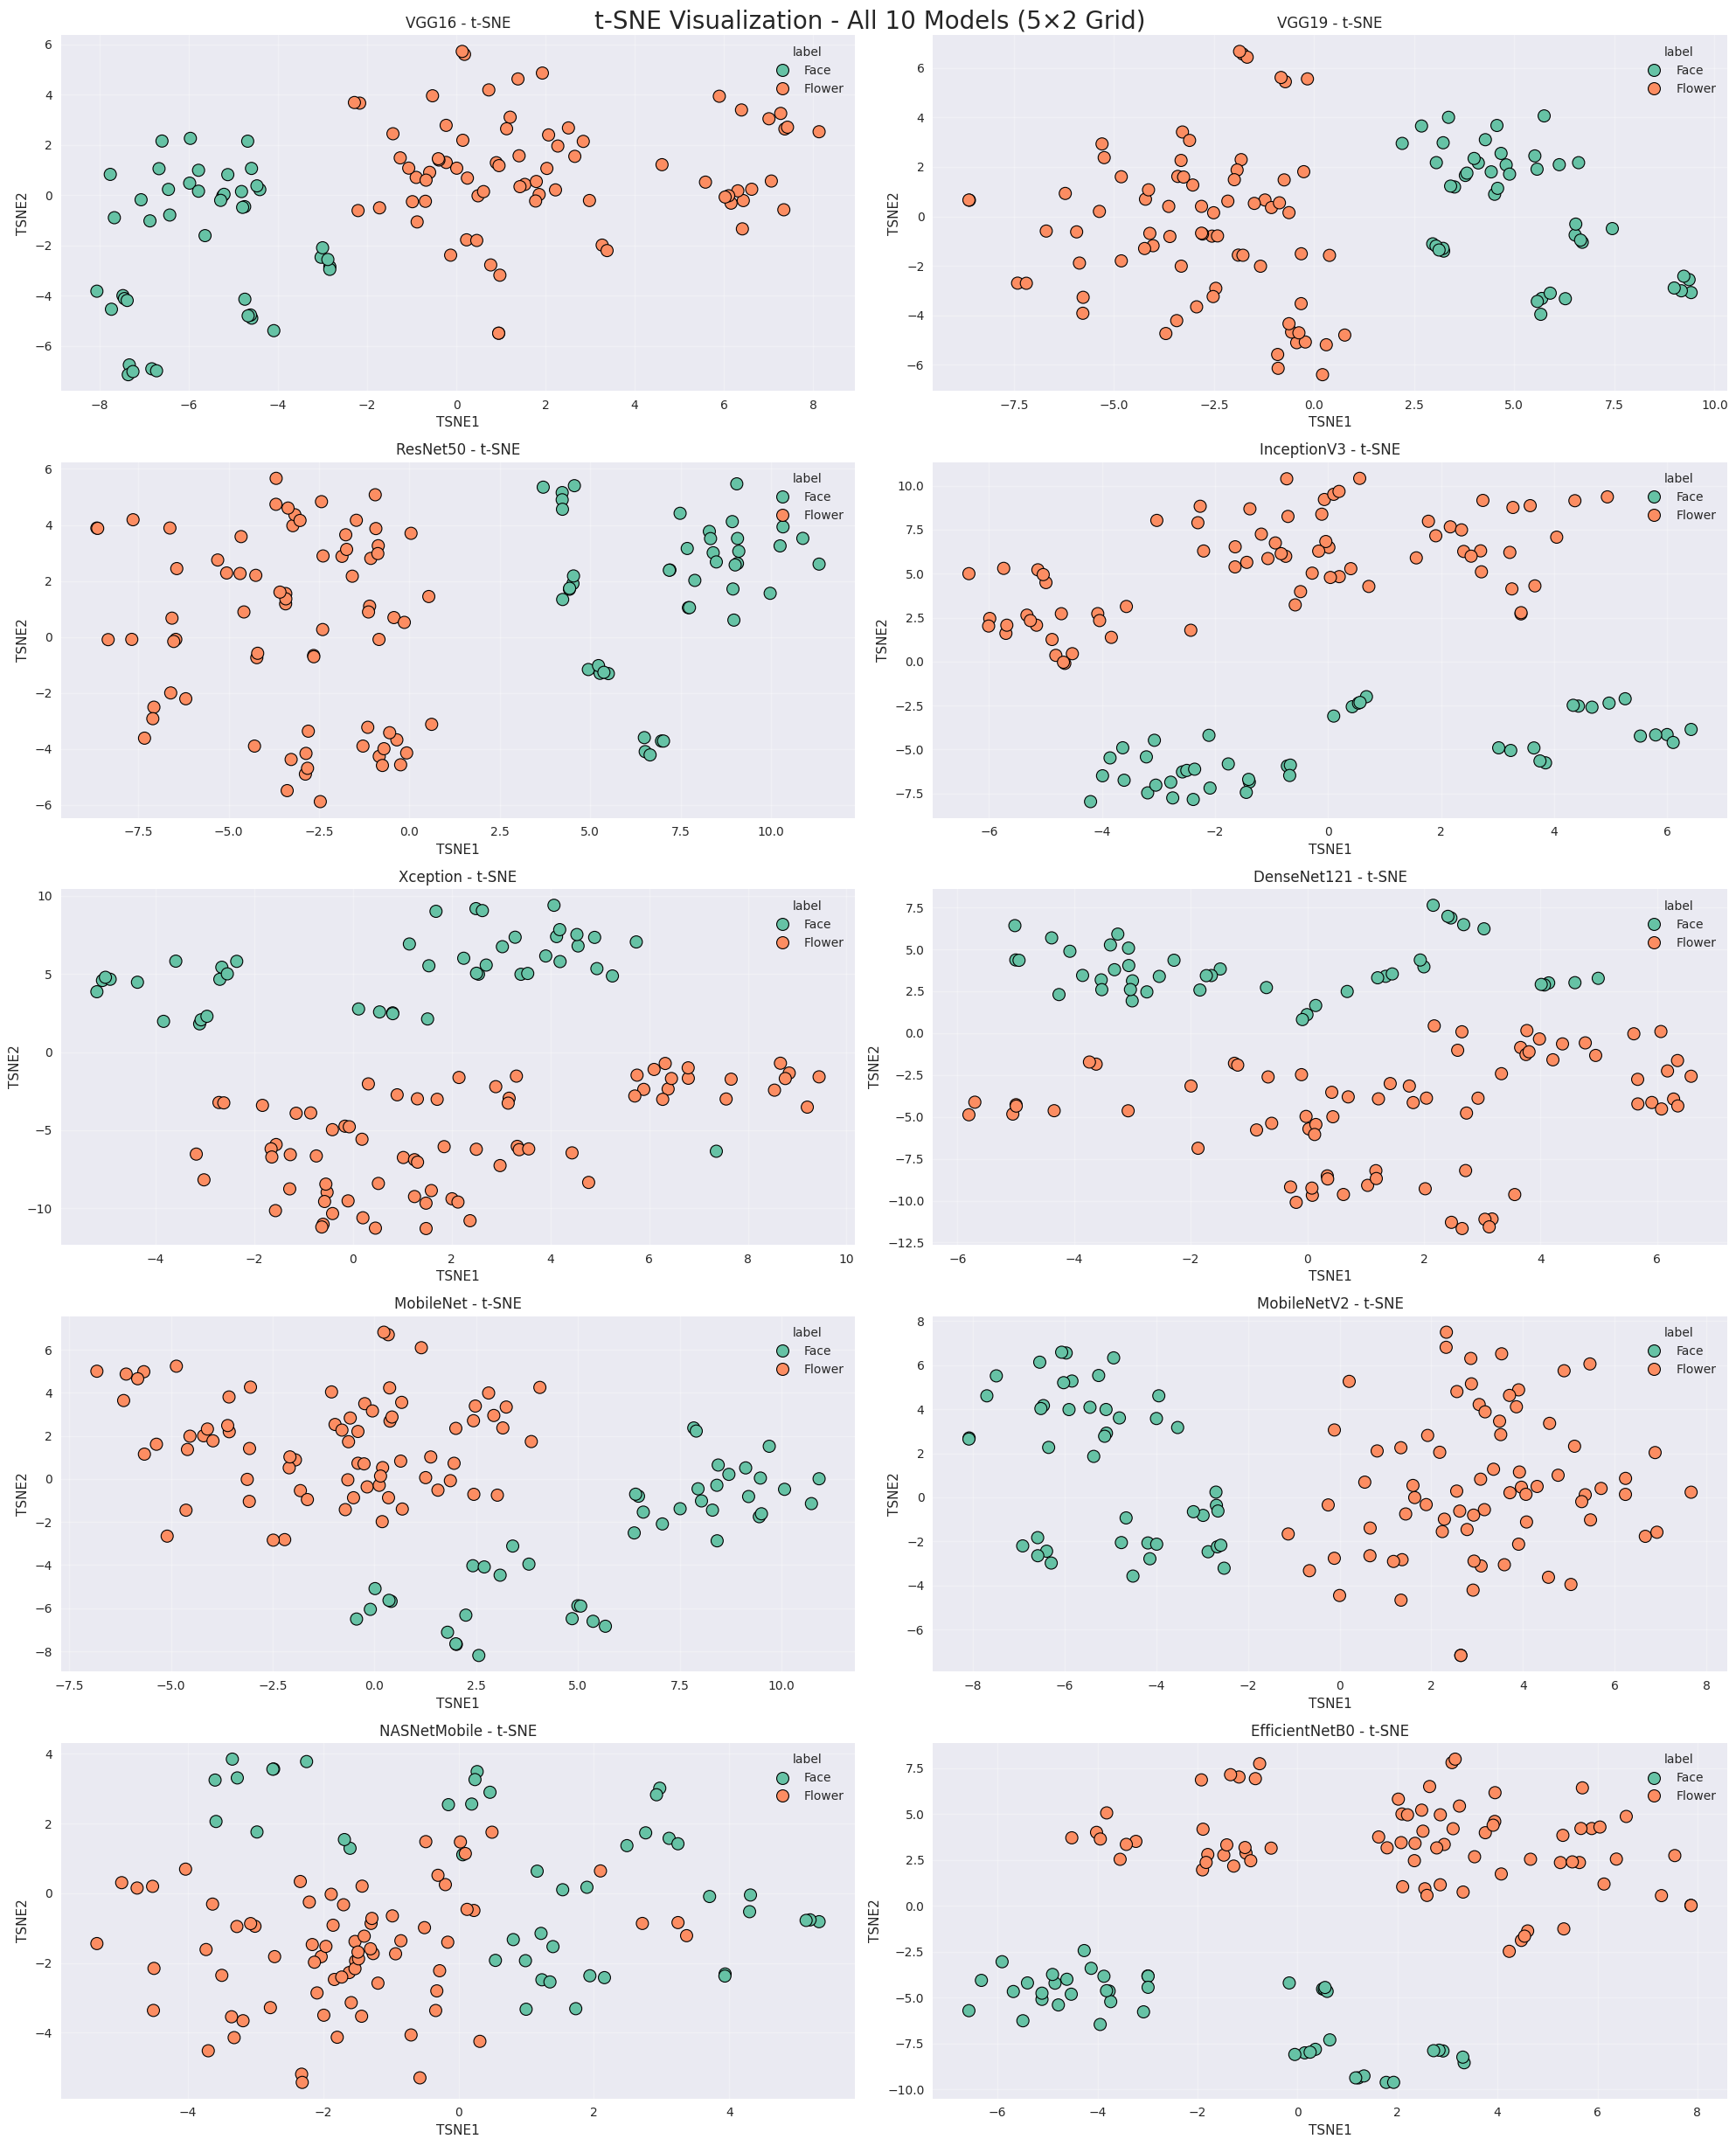

💾 Saved: ALL_MODELS_TSNE_Grid.png


In [23]:
from sklearn.manifold import TSNE

print("\n=== PART 3: Running t-SNE for all 10 models ===")

tsne_plots = []
for model_name in models_dict.keys():
    features = extract_features(model_name)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # Pre-reduce with PCA for speed
    if features.shape[1] > 50:
        pca_temp = PCA(n_components=50, random_state=42)
        features_scaled = pca_temp.fit_transform(features_scaled)
    
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, init='pca', random_state=42)
    embedding = tsne.fit_transform(features_scaled)
    
    df = pd.DataFrame(embedding, columns=['TSNE1', 'TSNE2'])
    df['label'] = labels
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='label', palette='Set2', s=120, edgecolor='black')
    plt.title(f'{model_name} - t-SNE')
    plt.savefig(f"{model_name}_TSNE.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    tsne_plots.append((model_name, df))
    print(f"✓ t-SNE done for {model_name}")

# ================ 10×2 GRID for t-SNE ================
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.ravel()

for i, (model_name, df) in enumerate(tsne_plots):
    sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='label', 
                    palette='Set2', s=100, edgecolor='black', ax=axes[i])
    axes[i].set_title(f'{model_name} - t-SNE')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('t-SNE Visualization - All 10 Models (5×2 Grid)', fontsize=20, y=0.98)
plt.tight_layout()
plt.savefig("ALL_MODELS_TSNE_Grid.png", dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: ALL_MODELS_TSNE_Grid.png")

### PART 4: UMAP for All 10 Models


=== PART 4: Running UMAP for all 10 models ===
Extracting features with VGG16 ...
✓ VGG16 → Features shape: (117, 512)
✓ UMAP done for VGG16
Extracting features with VGG19 ...
✓ VGG19 → Features shape: (117, 512)
✓ UMAP done for VGG19
Extracting features with ResNet50 ...
✓ ResNet50 → Features shape: (117, 2048)
✓ UMAP done for ResNet50
Extracting features with InceptionV3 ...
✓ InceptionV3 → Features shape: (117, 2048)
✓ UMAP done for InceptionV3
Extracting features with Xception ...
✓ Xception → Features shape: (117, 2048)
✓ UMAP done for Xception
Extracting features with DenseNet121 ...
✓ DenseNet121 → Features shape: (117, 1024)
✓ UMAP done for DenseNet121
Extracting features with MobileNet ...
✓ MobileNet → Features shape: (117, 1024)
✓ UMAP done for MobileNet
Extracting features with MobileNetV2 ...
✓ MobileNetV2 → Features shape: (117, 1280)
✓ UMAP done for MobileNetV2
Extracting features with NASNetMobile ...
✓ NASNetMobile → Features shape: (117, 1056)
✓ UMAP done for NASNetM

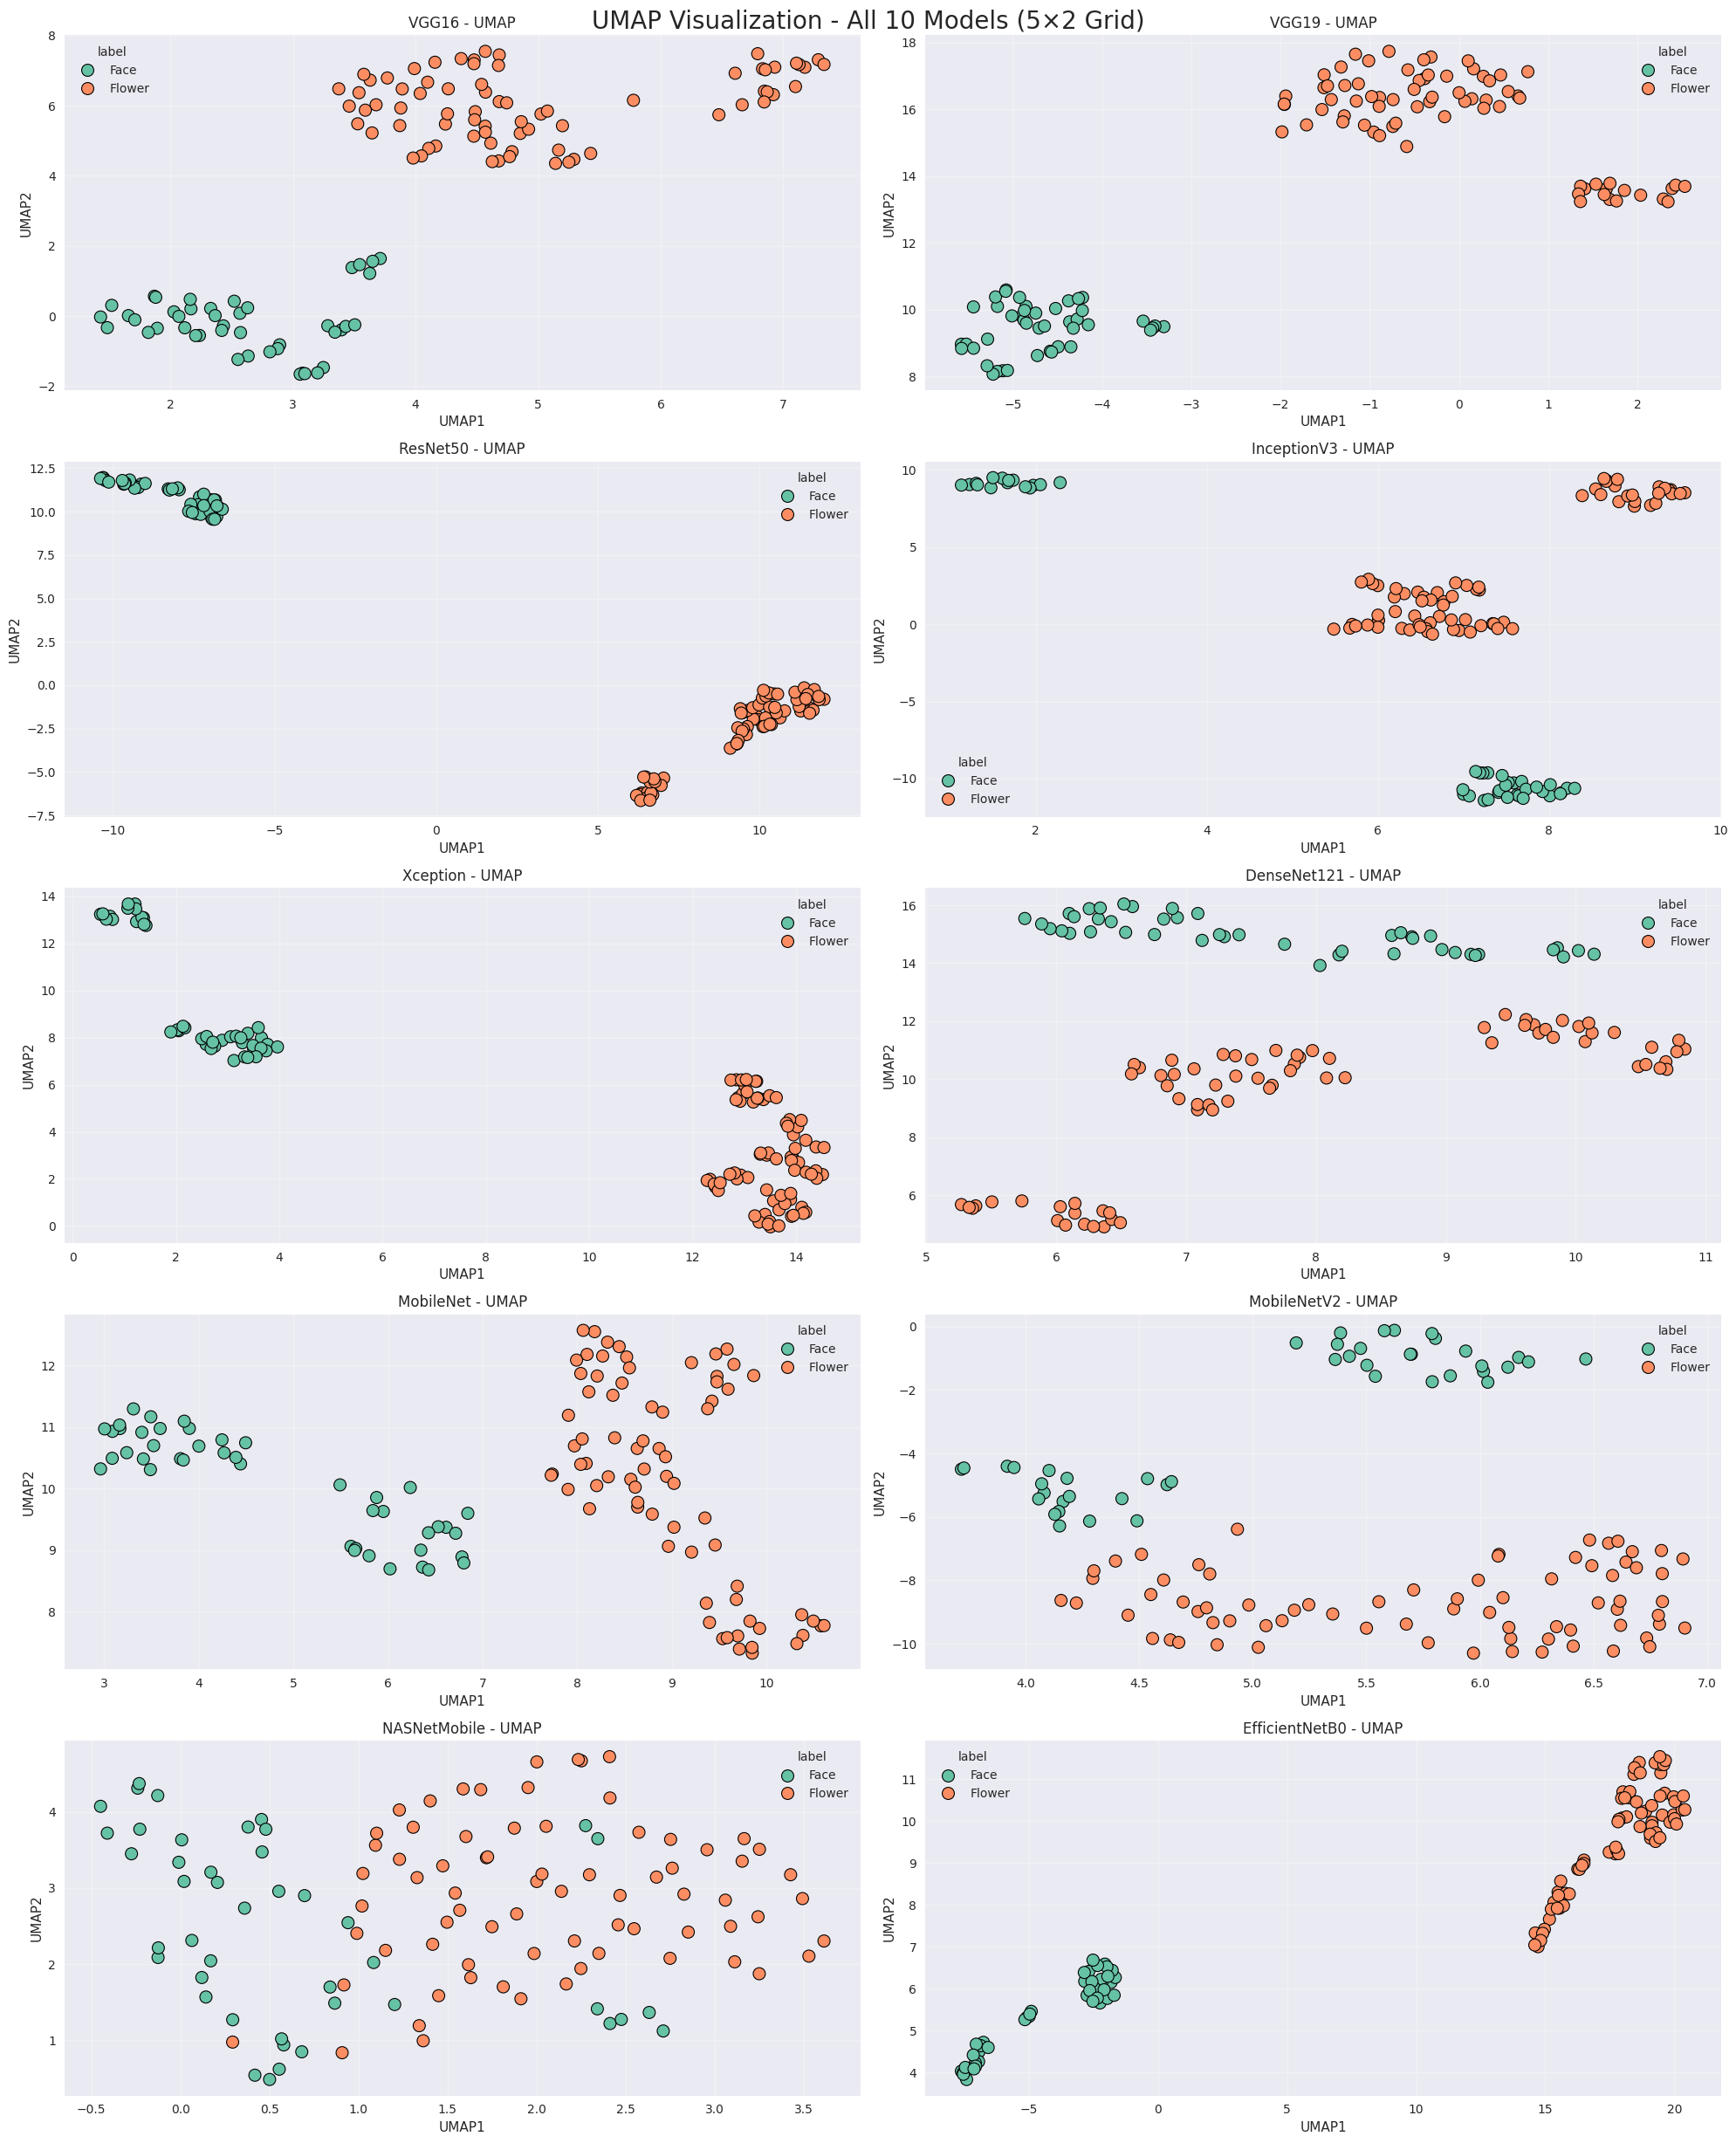

💾 Saved: ALL_MODELS_UMAP_Grid.png


In [24]:
import umap

print("\n=== PART 4: Running UMAP for all 10 models ===")

umap_plots = []
for model_name in models_dict.keys():
    features = extract_features(model_name)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(features_scaled)
    
    df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
    df['label'] = labels
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue='label', palette='Set2', s=120, edgecolor='black')
    plt.title(f'{model_name} - UMAP')
    plt.savefig(f"{model_name}_UMAP.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    umap_plots.append((model_name, df))
    print(f"✓ UMAP done for {model_name}")

# ================ 10×2 GRID for UMAP ================
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.ravel()

for i, (model_name, df) in enumerate(umap_plots):
    sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue='label', 
                    palette='Set2', s=100, edgecolor='black', ax=axes[i])
    axes[i].set_title(f'{model_name} - UMAP')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('UMAP Visualization - All 10 Models (5×2 Grid)', fontsize=20, y=0.98)
plt.tight_layout()
plt.savefig("ALL_MODELS_UMAP_Grid.png", dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: ALL_MODELS_UMAP_Grid.png")

### 5. Discussion

The visualization of features extracted from 10 pre-trained ImageNet models using three different dimensionality reduction techniques (PCA, t-SNE, and UMAP) provides valuable insights into how well each model represents the two classes: **Face** and **Flower**.

#### 5.1 Overall Class Separation Quality

Across all three techniques, a clear and consistent pattern emerges: **Face** and **Flower** images form two distinct clusters in the 2D embedding space for almost all models. This indicates that the pre-trained convolutional neural networks are able to learn meaningful high-level features that differentiate the two categories, even though they were originally trained on the 1000-class ImageNet dataset.

- **PCA** (linear method) shows reasonably good separation in most models, but the clusters are sometimes more spread out or overlapping (e.g., VGG19, DenseNet121, EfficientNetB0). This is expected because PCA captures global variance and may not preserve complex local structures.
- **t-SNE** and **UMAP** (non-linear manifold learning methods) generally provide **superior and more compact cluster separation** compared to PCA. The clusters appear tighter and more clearly separated, especially in t-SNE and UMAP plots.

#### 5.2 Model-wise Performance Analysis

**Best Performing Models:**
- **ResNet50**, **InceptionV3**, **Xception**, and **MobileNet** consistently show excellent separation between Face and Flower classes across all three techniques. 
  - In UMAP and t-SNE, these models produce very tight, well-defined clusters with minimal overlap.
  - This suggests that deeper residual architectures (ResNet) and inception-style models are particularly effective at extracting discriminative features for this binary classification task.

**Good but Slightly Weaker Models:**
- **VGG16** and **VGG19** show decent separation, but the Flower cluster is somewhat more dispersed in PCA and t-SNE. VGG models tend to produce broader distributions, indicating they capture more general features but may be less specialized.

**Moderate Performers:**
- **DenseNet121**, **MobileNetV2**, **NASNetMobile**, and **EfficientNetB0** show acceptable separation, but with more scattered points or minor overlap in some projections (especially visible in PCA). 
  - EfficientNetB0, despite being a highly efficient modern architecture, shows relatively loose clustering in PCA, though it improves significantly in UMAP.

#### 5.3 Why Some Models Perform Better

- **Architectural Advantages**: ResNet50 and Xception benefit from residual connections and multi-scale feature extraction, allowing them to learn richer hierarchical representations. This results in better separation even in lower-dimensional projections.
- **Feature Richness**: Models like InceptionV3 and Xception use parallel convolutional paths, enabling them to capture both fine details (important for faces) and global patterns (important for flowers) more effectively.
- **Dimensionality Reduction Sensitivity**: Linear PCA struggles more with complex non-linear relationships learned by modern CNNs, which is why t-SNE and UMAP reveal clearer separation for most models.

#### 5.4 Key Observations from the Grids

- In the **UMAP grid**, the separation is particularly clean for ResNet50, Xception, and MobileNet.
- In the **t-SNE grid**, Face and Flower clusters are very well isolated in most models, with only minor outliers.
- **PCA grid** shows more overlap and elongated clusters, confirming that non-linear methods (t-SNE & UMAP) are better suited for visualizing the complex feature spaces produced by deep CNNs.

#### 5.5 Conclusion on Feature Representation

Among the 10 models tested, **ResNet50**, **Xception**, and **InceptionV3** demonstrate the strongest feature representation capability for distinguishing between Face and Flower images. These models not only achieve high Top-1 accuracy in classification tasks but also produce highly separable embeddings in 2D space.

This analysis confirms that pre-trained models can be effectively used as powerful feature extractors even for domain-specific binary tasks, with residual and inception-based architectures showing superior performance in this case.

---